In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


In [4]:
df=pd.read_csv(r"D:\weightheight.csv")
df

,Weight,Height
0,45,120
1,50,130
2,60,160
3,55,155
4,45,140
5,68,168
6,70,180
7,80,190
8,88,195
9,62,162


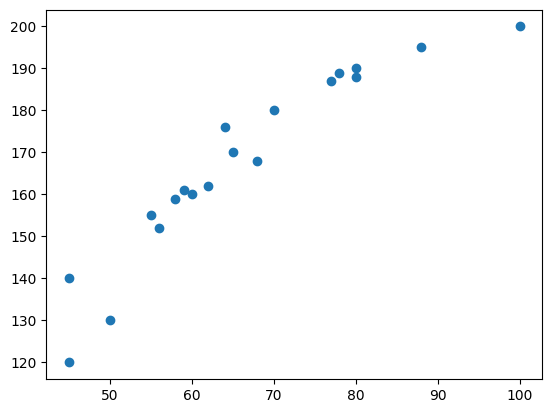

In [5]:
#scatter plt
plt.scatter(df['Weight'],df['Height'])

In [6]:
#correlation 
df.corr()

,Weight,Height
Weight,1.00000,0.93773
Height,0.93773,1.00000


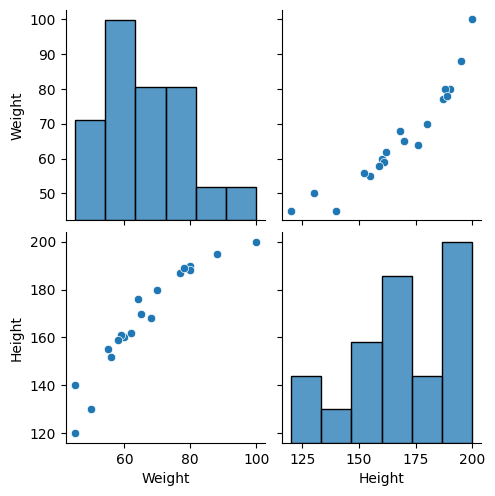

In [8]:
import seaborn as sns
sns.pairplot(df)

In [9]:
#independaent and dependent
df.head()

,Weight,Height
0,45,120
1,50,130
2,60,160
3,55,155
4,45,140


In [ ]:
x=df[['Weight']] #double bracket for the type to be Dataframe and 2D array
y=df['Height']#this var can be in series adnd 1D array
np.array(x).shape

(19, 1)

In [16]:
x_series=df['Weight']
np.array(x_series).shape

(19,)

In [31]:
# train test split
from sklearn.model_selection import train_test_split
x_t,x_test,y_t,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [32]:
np.array(x_test).shape

(4, 1)

In [33]:
#standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_t=scaler.fit_transform(x_t)

In [34]:
x_test=scaler.transform(x_test)

In [39]:
#apply linear regression
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)
regression.fit(x_t,y_t)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [ ]:
regression.coef_  #slope 
print(regression.coef_)
regression.intercept_# intercept

[16.69868017]


np.float64(173.66666666666666)

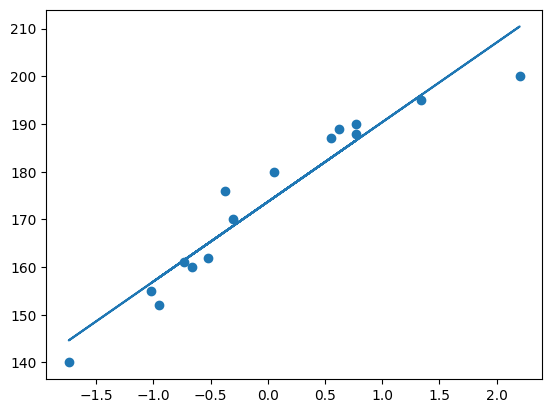

In [46]:
#plot training data
plt.scatter(x_t,y_t)
plt.plot(x_t,regression.predict(x_t))

In [48]:
#prediction for test data
# predicted=intercept+coef(weigth
y_pred=regression.predict(x_test)


In [49]:
#performance
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [52]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print(mse)
print(mae)

262.49808520916724
12.643629889989498


In [54]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.3323844598081901


In [56]:
%pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement statsmodel (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for statsmodel


In [59]:
#OLS technique
import statsmodels.api as sm 
model=sm.OLS(y_t,x_t).fit()
pred=model.predict(x_test)
print(pred)

[-29.03869387  -1.515756   -13.48225073 -23.05544651]


In [60]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.009
Model:                            OLS   Adj. R-squared (uncentered):             -0.062
Method:                 Least Squares   F-statistic:                             0.1293
Date:                Sat, 20 Jun 2026   Prob (F-statistic):                       0.724
Time:                        19:04:06   Log-Likelihood:                         -98.647
No. Observations:                  15   AIC:                                      199.3
Df Residuals:                      14   BIC:                                      200.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

C:\Users\RAJDEEP\AppData\Roaming\Python\Python313\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [61]:
regression.predict(scaler.transform([[66]]))

C:\Users\RAJDEEP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([169.75761172])